In [1]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

# Source - https://stackoverflow.com/a
# Posted by dfrankow
# Retrieved 2026-01-16, License - CC BY-SA 3.0

options(repr.matrix.max.rows=600, repr.matrix.max.cols=200)

In [2]:
tools = c('singlem', 'sylph', 'singlem_dev', 'singlem_joint', 'singlem_inject',
          'singlem_nnls', 'singlem_truecov')
publication_names = data.table(
    tool = tools,
    publication_name = c('SingleM', 'sylph', 'SingleM dev', 'SingleM joint', 'SingleM inject',
                         'SingleM nnls', 'SingleM truecov')
)
communities = paste0('sample',as.character(c(4, 5)))
dominance = 50
d1 = data.table(expand.grid(tool = tools, community = communities, dominance = dominance))
d1[, tool2 := publication_names[tool, on = "tool", publication_name]]
# output_singlem/opal/GCA_022615805.1_genomic.opal_report
readit = function(tool, community, dominance){
    to_read = paste0('output_',tool,'/opal/dominance', dominance, '/', community,'.opal_report')
    return(fread(to_read))
}
d2 = d1[, readit(tool, community, dominance), by=list(tool, community, dominance, tool2)]

In [3]:
setnames(d2, c('tool', 'community', 'dominance', 'tool2', 'blah', 'rank', 'metric', 'sample', 'value'))
d3 = d2[blah != 'Gold standard', .(tool, community, rank, metric, value, tool2)]
d3[, rank := factor(rank, c('kingdom','phylum','class','order','family','genus','species'))]

In [4]:
s1 = dcast(d3, ...~metric, value.var='value')
s1[, c("tool", "tool2") := list(tool2, NULL)]

s1 = s1[order(rank, tool)]
fwrite(s1, 'opal_summary.csv', sep='\t')

Warning message:
“Removed 14 rows containing missing values or values outside the scale range
(`stat_boxplot()`).”


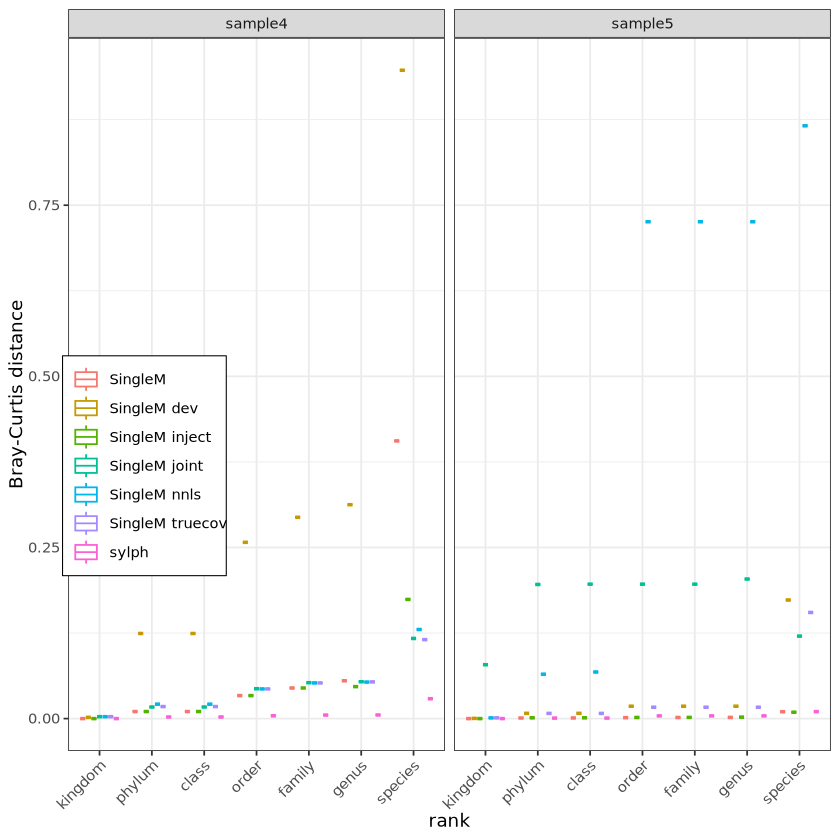

In [5]:
# Remove figure legend title, and put the legend in bottom left of plot, with a bounding box
ggplot(s1, aes(rank, `Bray-Curtis distance`, colour = tool)) +
   geom_boxplot() +
   scale_x_discrete(na.translate = FALSE) +
   theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
   theme(legend.title=element_blank()) +
   theme(legend.position=c(0.1,0.4)) +
   theme(legend.background = element_rect(colour = "black", linewidth = 0.3)) +
   facet_wrap(vars(community))

# Relationship between relative abundance and accuracy

In [6]:
truth_profiles = data.table(expand.grid(community=communities, dominance=dominance))
truth_profiles2 = truth_profiles[
    ,
    fread(paste('truths/dominance', dominance, '/',community,'.condensed',sep=''),
          colClasses = c("coverage" = "double")),
    by=list(community, dominance)
]
truth_profiles2[, c("sample", "tool") := .(NULL, 'Gold standard')]

In [7]:
tool_profiles = data.table(expand.grid(tool = tools, community = communities, dominance = dominance))
tool_profiles2 = tool_profiles[
    ,
    fread(paste('output_',tool,'/',tool,'/dominance',dominance, '/', community,'.profile',sep='')),
    by=list(tool,community,dominance)
]
tool_profiles2[
    ,
    `:=`(sample = NULL,
         taxonomy = gsub('Root;','',gsub('; ',';',taxonomy)),
         tool = factor(publication_names[tool, on = "tool", publication_name]))
]

all_profiles = rbind(truth_profiles2, tool_profiles2)
all_profiles[, relabu := coverage / sum(coverage), by = list(community, tool)]
m = dcast(all_profiles, taxonomy + community ~ tool, value.var = c("relabu", "coverage"), fill = 0)
setnames(m, names(m), gsub("_", "__", names(m)))
setnames(m, c("relabu__Gold standard", "coverage__Gold standard"), c("true_relabu", "true_coverage"))

In [8]:
# singlem and sylph relative abundances
format_table <- function(m) {
    ra_cols <- grep("^relabu_|_relabu$", names(m), value = TRUE)
    mtmp = m[, which(!grepl("^coverage_|_coverage$", names(m))), with = FALSE]
    mtmp[
        ,
        c(ra_cols, "taxonomy") := c(
            lapply(.SD, scales::label_percent()),
            list(purrr::map_chr(strsplit(taxonomy, "; ?"), function(x) paste0(tail(x,2), collapse = "; ")))
        ),
        .SDcols = ra_cols
    ][order(community, taxonomy)]
}

In [9]:
# singlem coverages
format_table_cov <- function(m) {
    cov_cols <- grep("^coverage_|_coverage$", names(m), value = TRUE)
    mtmp = m[, which(!grepl("^relabu_|_relabu$", names(m))), with = FALSE]
    mtmp[
        ,
        c(cov_cols, "taxonomy") := c(
            .SD,
            list(purrr::map_chr(strsplit(taxonomy, "; ?"), function(x) paste0(tail(x,2), collapse = "; ")))
        ),
        .SDcols = cov_cols
    ][order(community, taxonomy)]
}

In [10]:
# kingdom
#format_table(m[grep("d__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";p__.*", "", taxonomy))])
format_table_cov(m[grep("d__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";p__.*", "", taxonomy))])

community,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__SingleM nnls,coverage__SingleM truecov,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,d__Archaea,0.0,0.00,0.31,0.00,0.40,0.40,0.40,0.000
sample4,d__Bacteria,180.0,175.69,172.51,175.69,140.78,142.74,142.06,189.974
sample5,d__Archaea,0.0,0.00,0.42,0.00,1.05,0.13,1.22,0.000
sample5,d__Bacteria,1367.2,1352.98,1354.84,1354.36,12.29,125.40,1100.41,1376.614


In [11]:
# phylum
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";p__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";c__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";p__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";c__.*", "", taxonomy))])

community,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__SingleM nnls,coverage__SingleM truecov,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,d__Bacteria; p__Actinobacteriota,99.0,96.86,89.94,96.86,76.65,76.99,77.21,104.428
sample4,d__Bacteria; p__Bacteroidota,9.0,8.29,3.57,8.29,6.96,6.96,7.04,9.768
sample4,d__Bacteria; p__Cyanobacteria,6.0,5.97,2.25,5.97,4.71,4.99,4.77,6.392
sample4,d__Bacteria; p__Desulfobacterota_I,3.0,3.29,0.79,3.29,3.13,3.15,3.15,3.202
sample4,d__Bacteria; p__Firmicutes,18.0,17.05,13.28,17.05,14.50,15.46,14.67,18.877
sample4,d__Bacteria; p__Firmicutes_A,6.0,5.17,0.00,5.17,4.68,4.68,4.73,6.358
sample4,d__Bacteria; p__Firmicutes_B,3.0,2.51,0.00,2.51,1.89,2.25,1.92,3.225
sample4,d__Bacteria; p__Planctomycetota,0.0,0.00,0.00,0.00,0.06,0.06,0.06,0.000
sample4,d__Bacteria; p__Proteobacteria,33.0,32.80,24.77,32.80,26.59,26.61,26.88,34.666


In [12]:
# class
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";c__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";o__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";c__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";o__.*", "", taxonomy))])

community,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__SingleM nnls,coverage__SingleM truecov,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,p__Actinobacteriota; c__Actinomycetia,99.0,96.86,89.94,96.86,76.65,76.99,77.21,104.428
sample4,p__Bacteroidota; c__Bacteroidia,9.0,8.29,3.57,8.29,6.96,6.96,7.04,9.768
sample4,p__Cyanobacteria; c__Cyanobacteriia,6.0,5.97,2.25,5.97,4.71,4.99,4.77,6.392
sample4,p__Desulfobacterota_I; c__Desulfovibrionia,3.0,3.29,0.79,3.29,3.13,3.15,3.15,3.202
sample4,p__Firmicutes; c__Bacilli,18.0,17.05,13.28,17.05,14.50,15.46,14.67,18.877
sample4,p__Firmicutes_A; c__Clostridia,6.0,5.17,0.00,5.17,4.68,4.68,4.73,6.358
sample4,p__Firmicutes_B; c__Desulfitobacteriia,3.0,2.51,0.00,2.51,1.89,2.25,1.92,3.225
sample4,p__Planctomycetota; c__Planctomycetia,0.0,0.00,0.00,0.00,0.06,0.06,0.06,0.000
sample4,p__Proteobacteria; c__Gammaproteobacteria,33.0,32.80,24.77,32.80,26.59,26.61,26.88,34.666


In [13]:
# order
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";o__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";f__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";o__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";f__.*", "", taxonomy))])

community,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__SingleM nnls,coverage__SingleM truecov,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,c__Actinomycetia; o__Actinomycetales,6.0,6.20,2.88,6.20,4.37,4.36,4.41,6.204
sample4,c__Actinomycetia; o__Mycobacteriales,3.0,3.52,0.00,3.52,2.99,3.00,3.01,3.160
sample4,c__Actinomycetia; o__Streptomycetales,90.0,84.75,78.74,84.75,69.29,69.63,69.79,95.064
sample4,c__Bacilli; o__Bacillales_D,3.0,2.90,0.00,2.90,2.73,2.74,2.75,2.983
sample4,c__Bacilli; o__CAJFEE01,3.0,1.02,0.00,1.02,1.13,1.10,1.17,3.252
sample4,c__Bacilli; o__Erysipelotrichales,3.0,2.55,0.00,2.55,1.36,2.28,1.40,3.164
sample4,c__Bacilli; o__Lactobacillales,3.0,3.24,0.00,3.24,3.12,3.14,3.14,3.085
sample4,c__Bacilli; o__Staphylococcales,6.0,6.65,3.13,6.65,6.16,6.20,6.21,6.393
sample4,c__Bacteroidia; o__Bacteroidales,6.0,5.79,0.26,5.79,4.81,4.81,4.86,6.603


In [14]:
# family
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";f__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";g__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";f__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";g__.*", "", taxonomy))])

community,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__SingleM nnls,coverage__SingleM truecov,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,o__Actinomycetales; f__Bifidobacteriaceae,6.0,5.68,2.88,5.68,4.37,4.36,4.41,6.204
sample4,o__Bacillales_D; f__Amphibacillaceae,3.0,2.90,0.00,2.90,2.73,2.74,2.75,2.983
sample4,o__Bacteroidales; f__Porphyromonadaceae,3.0,3.24,0.00,3.24,2.78,2.79,2.80,3.193
sample4,o__Bacteroidales; f__Rikenellaceae,3.0,2.27,0.00,2.27,2.03,2.02,2.06,3.410
sample4,o__Burkholderiales; f__Burkholderiaceae,6.0,6.54,3.24,6.54,5.93,5.96,5.97,6.346
sample4,o__CACIAM-69d; f__CACIAM-69d,3.0,3.07,0.51,3.07,2.65,2.93,2.68,3.232
sample4,o__CAJFEE01; f__CAJFEE01,3.0,1.02,0.00,1.02,1.13,1.10,1.17,3.252
sample4,o__Chitinophagales; f__Saprospiraceae,3.0,2.33,0.00,2.33,2.15,2.15,2.18,3.165
sample4,o__Clostridiales; f__Clostridiaceae,3.0,2.44,0.00,2.44,2.35,2.35,2.38,3.286


In [15]:
# How well does genus level rescue some of the missing genomes? First need to remake the table with genus level, annoying since kraken profiles are filled, when the rest aren't.
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";g__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";s__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";g__", taxonomy), lapply(.SD, sum), by = list(community, taxonomy = gsub(";s__.*", "", taxonomy))])

community,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__SingleM nnls,coverage__SingleM truecov,coverage__sylph
<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,f__Amphibacillaceae; g__Virgibacillus,3.0,2.90,0.00,2.90,2.73,2.74,2.75,2.983
sample4,f__Bifidobacteriaceae; g__Bifidobacterium,6.0,5.68,2.88,5.68,4.37,4.36,4.41,6.204
sample4,f__Burkholderiaceae; g__Paraburkholderia,6.0,6.54,3.24,6.54,5.93,5.96,5.97,6.346
sample4,f__CACIAM-69d; g__CACIAM-69d,3.0,3.07,0.51,3.07,2.65,2.93,2.68,3.232
sample4,f__CAJFEE01; g__Harrysmithimonas,3.0,1.02,0.00,1.02,1.13,1.10,1.17,3.252
sample4,f__Clostridiaceae; g__Clostridium_H,3.0,2.44,0.00,2.44,2.35,2.35,2.38,3.286
sample4,f__Desulfitobacteriaceae; g__Desulfitobacterium,3.0,2.51,0.00,2.51,1.83,2.19,1.86,3.225
sample4,f__Desulfitobacteriaceae; g__Desulfosporosinus,0.0,0.00,0.00,0.00,0.06,0.06,0.06,0.000
sample4,f__Desulfovibrionaceae; g__Desulfovibrio,3.0,3.29,0.79,3.29,3.13,3.15,3.15,3.202


In [16]:
# Species level
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";s__", taxonomy)])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";s__", taxonomy)])

taxonomy,community,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__SingleM nnls,coverage__SingleM truecov,coverage__sylph
<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
g__Acinetobacter; s__Acinetobacter gandensis,sample4,3e+00,3.66,0.00,3.66,2.92,2.94,2.95,3.286
g__Acinetobacter; s__Acinetobacter gerneri,sample4,3e+00,3.22,0.00,3.22,2.71,2.72,2.73,3.206
g__Alistipes; s__Alistipes sp017517705,sample4,3e+00,2.27,0.00,2.27,2.03,2.02,2.06,3.410
g__Basfia; s__Basfia succiniciproducens,sample4,3e+00,2.22,0.00,2.22,2.09,2.09,2.12,3.055
g__Bifidobacterium; s__Bifidobacterium asteroides_E,sample4,3e+00,1.72,0.00,1.72,1.39,1.37,1.42,3.075
g__Bifidobacterium; s__Bifidobacterium ruminantium,sample4,3e+00,3.68,0.00,3.68,2.98,2.99,2.99,3.129
g__CACIAM-69d; s__CACIAM-69d sp001698445,sample4,3e+00,2.81,0.00,2.81,2.54,2.43,2.57,3.232
g__CACIAM-69d; s__CACIAM-69d sp001913845,sample4,0e+00,0.00,0.00,0.00,0.11,0.50,0.11,0.000
g__CAG-510; s__CAG-510 sp000434615,sample4,3e+00,2.28,0.00,2.28,2.33,2.33,2.35,3.072
